In [1]:
import os
from glob import glob
import pandas as pd
import geopandas as gpd
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt

%matplotlib widget

os.chdir('/store/carroll/col/data')

In [2]:
def closest_wl(wl, mv):
    return np.nanargmin(np.abs(wl-mv))
    
wl_neon = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000 # nm
wvl_col_neon = [f'w{x}' for x in wl_neon]
wl_neon_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')
wl_neon_nan[0:4] = np.nan
wl_neon_nan[-13:] = np.nan
wl_neon_nan[closest_wl(wl_neon_nan, 1355.388672)] = np.nan
wl_neon_nan[closest_wl(wl_neon_nan, 1350)] = np.nan
wl_neon_nan[closest_wl(wl_neon_nan, 1345)] = np.nan

In [16]:
fp = '2025/validation/rfl_pseudoinvariant_deploy6c20260214.csv'
df = pd.read_csv(fp)
df['year'] = df['fid'].str.extract(r'(2018|2025)')

columns = [x.replace('rfl_','') for x in df.columns]
df.columns = columns

df_mean = df.groupby(['site','fid','year'], as_index=False).mean()

sites_all = df.site.unique()

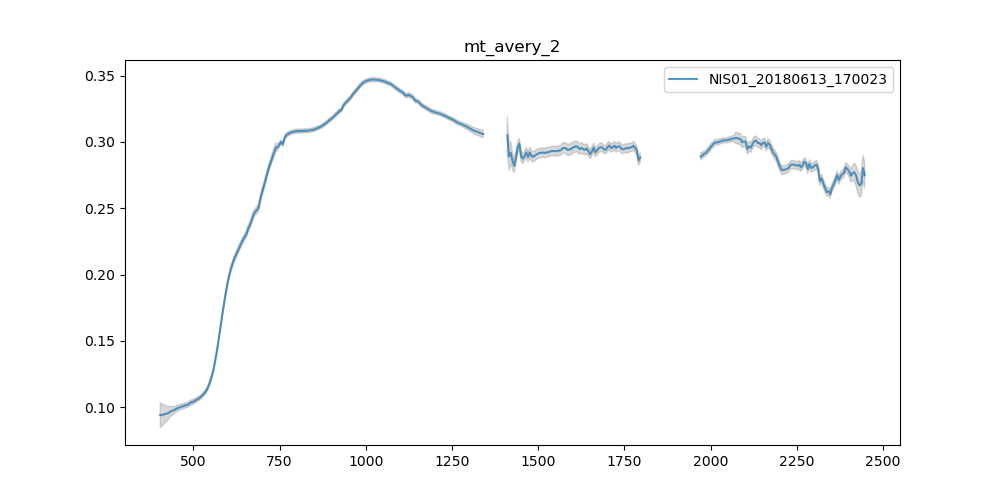

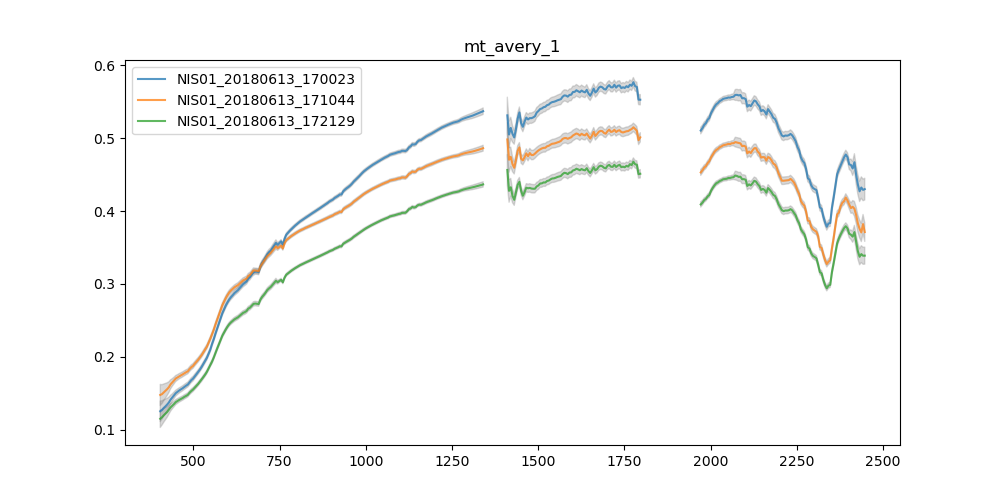

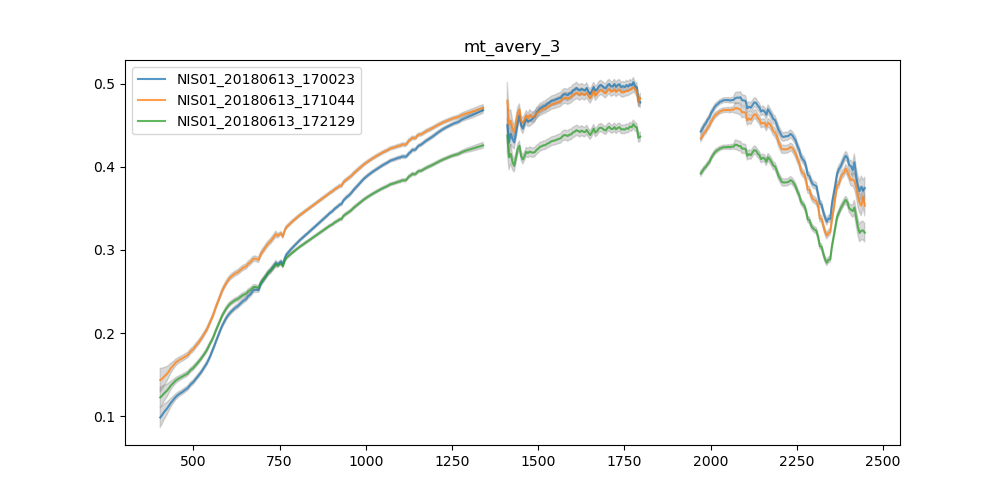

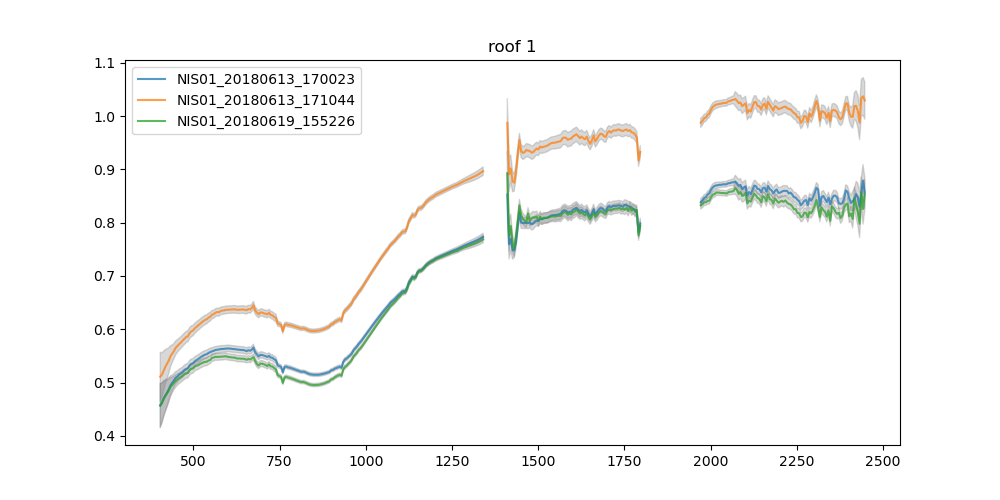

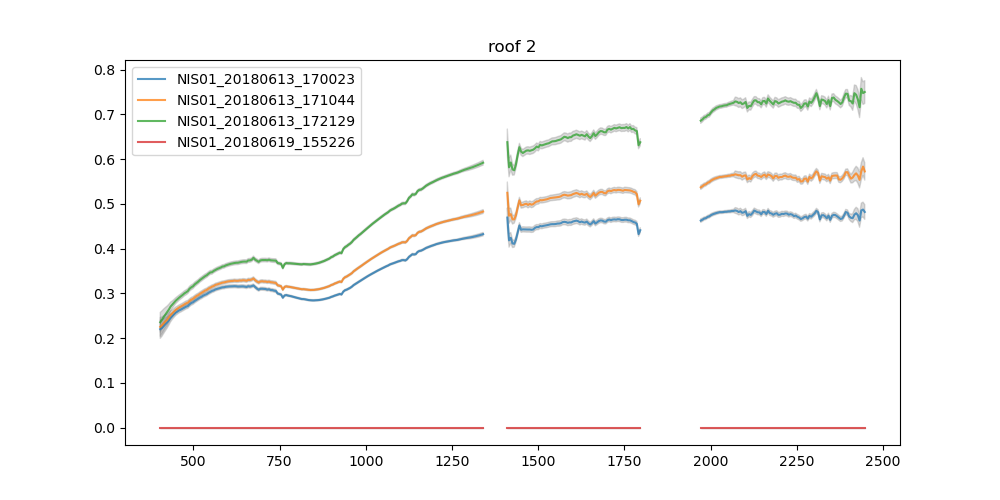

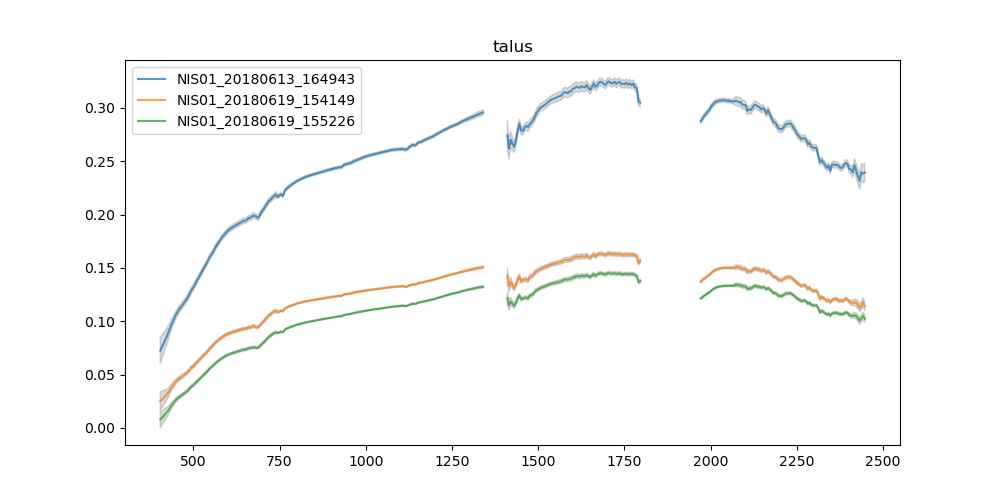

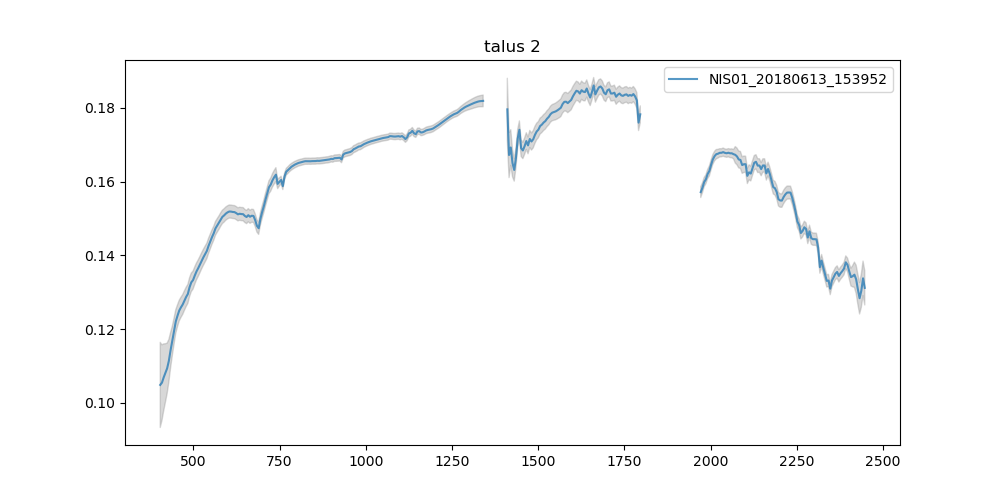

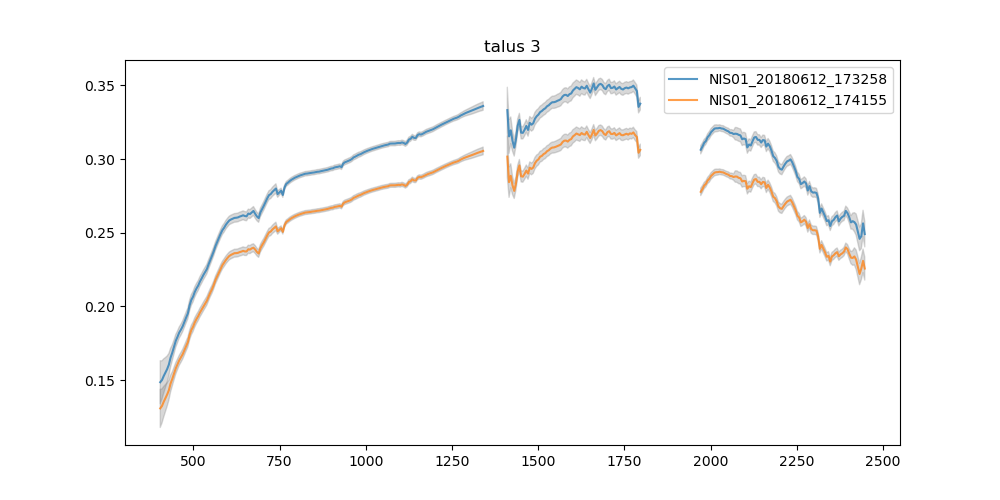

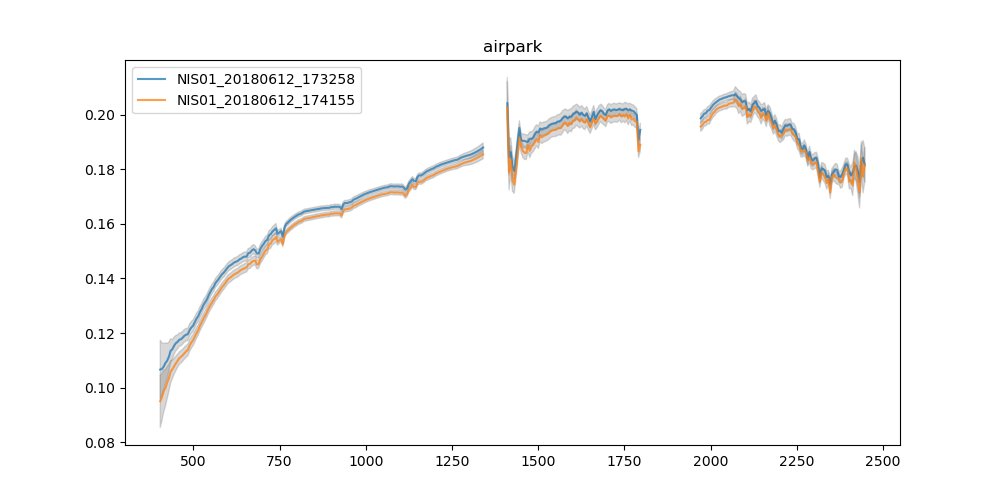

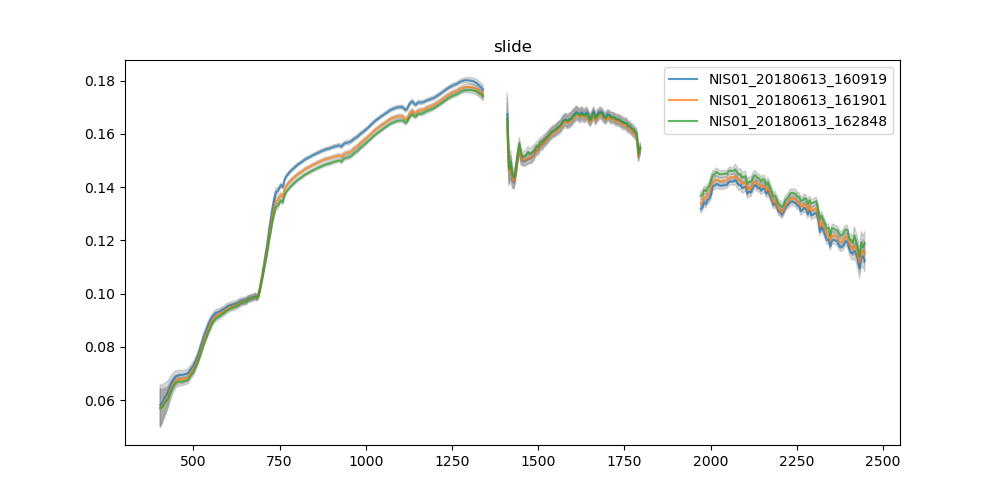

In [27]:
for site in sites_all:
    tmp = df_mean[df_mean['site']==site]
    rfl = np.asarray(tmp[wvl_col_neon])
    unc = np.asarray(tmp[['unc_'+x for x in wvl_col_neon]])
    dates = [x for x in tmp['fid']]
    lower = rfl - unc
    upper = rfl + unc
    
    fig, ax = plt.subplots(figsize=(10,5))

    for i in range(rfl.shape[0]):
        plt.fill_between(wl_neon_nan, lower[i,:], upper[i,:], alpha=0.3, color='gray') #, label="± Uncertainty"
        ax.plot(wl_neon_nan, rfl[i,:], alpha=0.75, label=dates[i]) # color='#1f77b4'
    
    plt.legend()
    plt.title(site)
    plt.show()